<a href="https://colab.research.google.com/github/alfathroziqq/PCD_Assignment_2_Kelompok/blob/main/Tugas_2_Kelompok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LIBRARY**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import io
from PIL import Image, ImageOps
from google.colab import files
from io import BytesIO

## **1. RGB**

Saving haha.png to haha (17).png


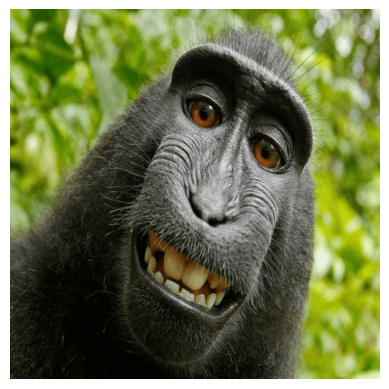

In [ ]:
def rgb_image():
    uploaded = files.upload()
    for filename in uploaded.keys():
        image_rgb = Image.open(io.BytesIO(uploaded[filename]))
        image_rgb = image_rgb.convert('RGB')

        # Show gambar
        plt.imshow(image_rgb)
        plt.axis('off')
        plt.show()

rgb_image()

## **2. RGB to Grayscale**

Saving haha.png to haha.png


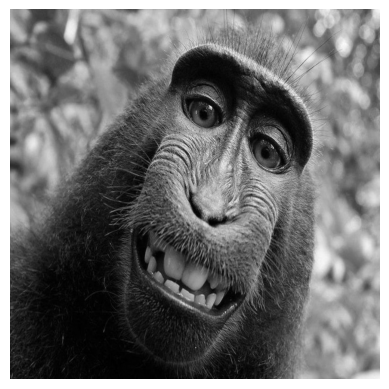

In [ ]:
def rgb_to_grayscale():
    uploaded = files.upload()
    for filename in uploaded.keys():
        image_to_grayscale = Image.open(io.BytesIO(uploaded[filename]))
        image_to_grayscale = image_to_grayscale.convert('L')

        # Show gambar
        plt.imshow(image_to_grayscale, cmap="gray")
        plt.axis('off')
        plt.show()

rgb_to_grayscale()

## **3. Grayscale to Biner**

Saving haha.png to haha (18).png


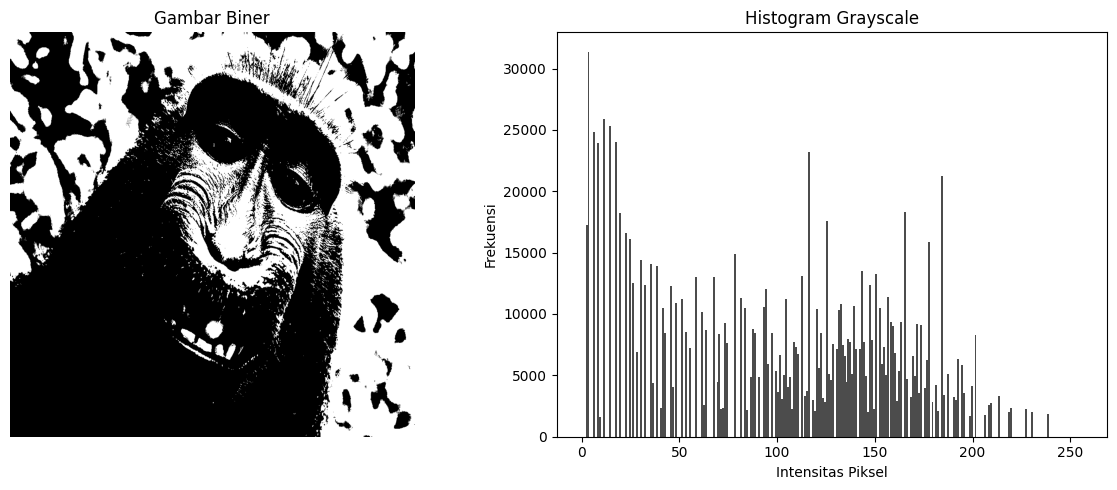

In [ ]:
def grayscale_to_biner():
    uploaded = files.upload()
    for filename in uploaded.keys():
        image = Image.open(io.BytesIO(uploaded[filename]))
        image = image.convert('L')

        # konversi ke biner
        threshold = 128
        binary_image = image.point(lambda p: 255 if p > threshold else 0, '1')
        image_np = np.array(image)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(binary_image, cmap='gray')
        axes[0].set_title('Gambar Biner')
        axes[0].axis('off')

        axes[1].hist(image_np.ravel(), bins=256, range=(0, 256), color='black', alpha=0.7)
        axes[1].set_title('Histogram Grayscale')
        axes[1].set_xlabel('Intensitas Piksel')
        axes[1].set_ylabel('Frekuensi')

        plt.tight_layout()
        plt.show()

grayscale_to_biner()

## **4. RGB to CMY**

Saving haha.png to haha (25).png


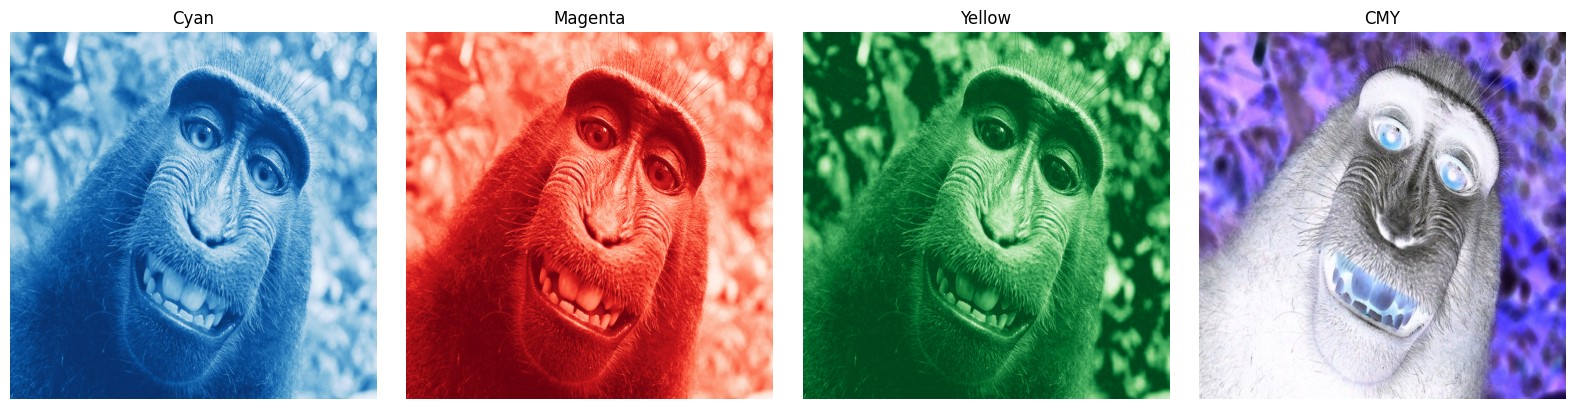

In [ ]:
def rgb_to_cmy():
    uploaded = files.upload()
    for filename in uploaded.keys():
        image = Image.open(io.BytesIO(uploaded[filename]))
        image = image.convert('RGB')

        img_rgb = np.array(image) / 255.0

        # konversi ke CMY
        C = 1.0 - img_rgb[:, :, 0]
        M = 1.0 - img_rgb[:, :, 1]
        Y = 1.0 - img_rgb[:, :, 2]

        cmy_images = [C, M, Y]
        cmy_titles = ['Cyan', 'Magenta', 'Yellow']
        cmy_cmaps = ['Blues', 'Reds', 'Greens']

        combined_cmy = np.stack([C, M, Y], axis=-1)

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))

        for i in range(3):
            axes[i].imshow(cmy_images[i], cmap=cmy_cmaps[i])
            axes[i].set_title(cmy_titles[i])
            axes[i].axis('off')

        axes[3].imshow(combined_cmy)
        axes[3].set_title('CMY')
        axes[3].axis('off')

        plt.tight_layout()
        plt.show()

rgb_to_cmy()

## **5. RGB to HSI**

Saving haha.png to haha (26).png


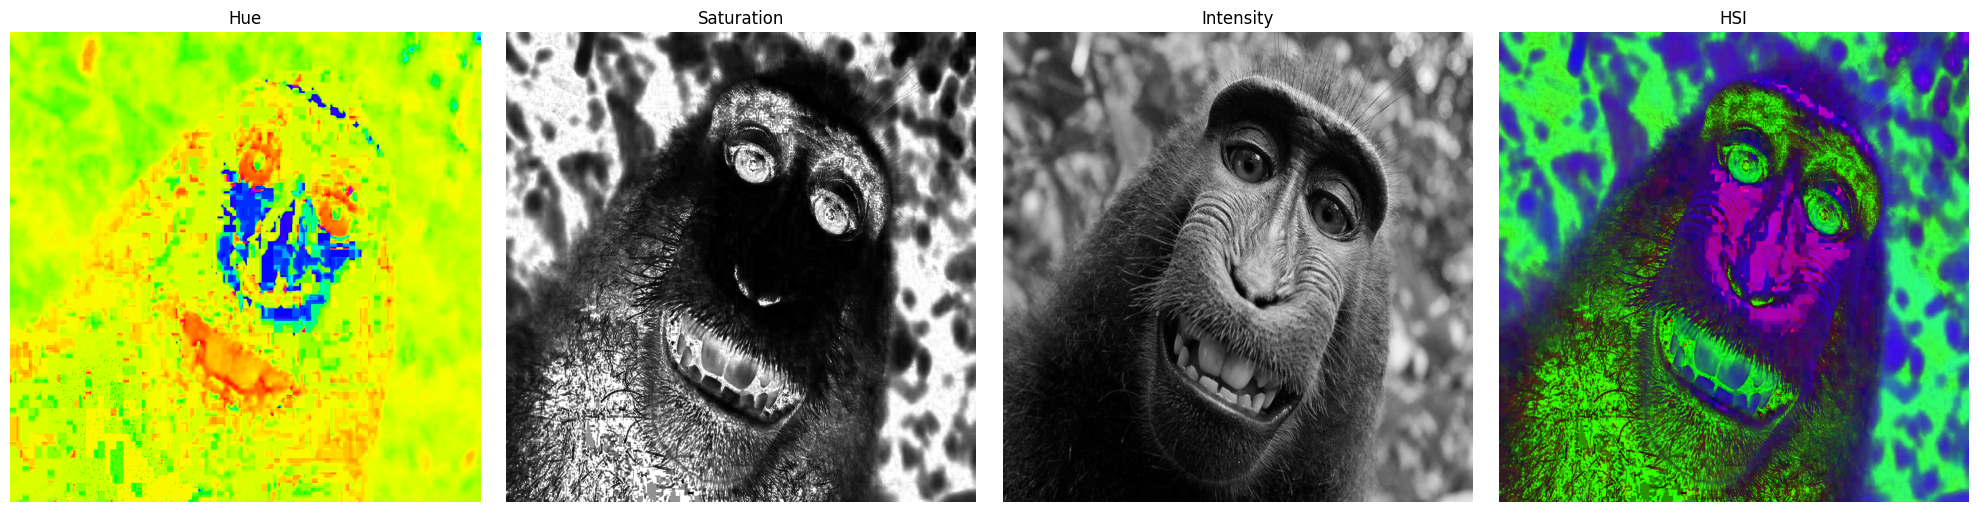

In [ ]:
def rgb_to_hsi():
    uploaded = files.upload()
    for filename in uploaded.keys():
        image_rgb = Image.open(io.BytesIO(uploaded[filename]))
        image_rgb = image_rgb.convert('RGB')

        img_rgb = np.array(image_rgb) / 255.0
        R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]

        # konversi ke HSI
        I = np.mean(img_rgb, axis=2)
        min_rgb = np.min(img_rgb, axis=2)
        S = 1 - (min_rgb / (I + 1e-10))

        num = 0.5 * ((R - G) + (R - B))
        den = np.sqrt((R - G) ** 2 + (R - B) * (G - B)) + 1e-10
        theta = np.arccos(num / den)

        H = np.where(B > G, 2 * np.pi - theta, theta)
        H = H / (2 * np.pi)

        HSI_combined = np.stack([H, S, I], axis=2)

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))

        axes[0].imshow(H, cmap='hsv')
        axes[0].set_title('Hue')
        axes[0].axis('off')

        axes[1].imshow(S, cmap='gray')
        axes[1].set_title('Saturation')
        axes[1].axis('off')

        axes[2].imshow(I, cmap='gray')
        axes[2].set_title('Intensity')
        axes[2].axis('off')

        axes[3].imshow(HSI_combined)
        axes[3].set_title('HSI')
        axes[3].axis('off')

        plt.tight_layout()
        plt.show()

rgb_to_hsi()

## **6. Transformasi Negatif**

Saving Screenshot 2025-03-20 160502.png to Screenshot 2025-03-20 160502 (8).png


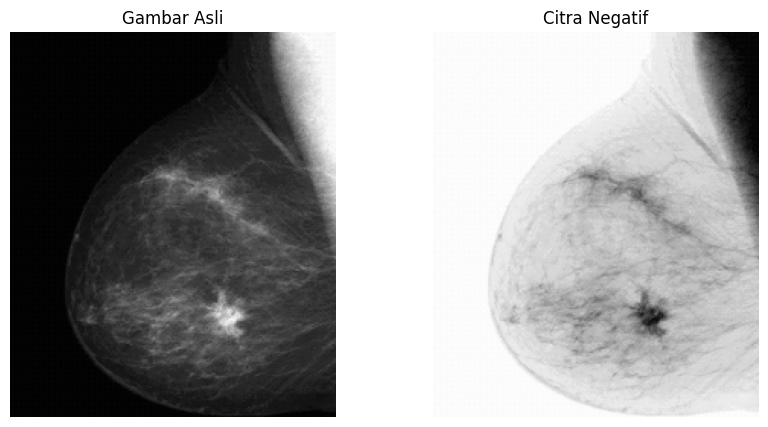

In [ ]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

def negative_transformation():
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]

    gray_image = Image.open(file_name).convert('L')
    gray_array = np.array(gray_image)

    # transformasi negatif
    L = 256
    negative_array = (L - 1) - gray_array
    negative_image = Image.fromarray(negative_array)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(gray_image, cmap='gray')
    plt.title('Gambar Asli')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(negative_image, cmap='gray')
    plt.title('Citra Negatif')
    plt.axis('off')

    plt.show()

negative_transformation()

## **7. Inversi Citra**

Saving monyet.png to monyet.png


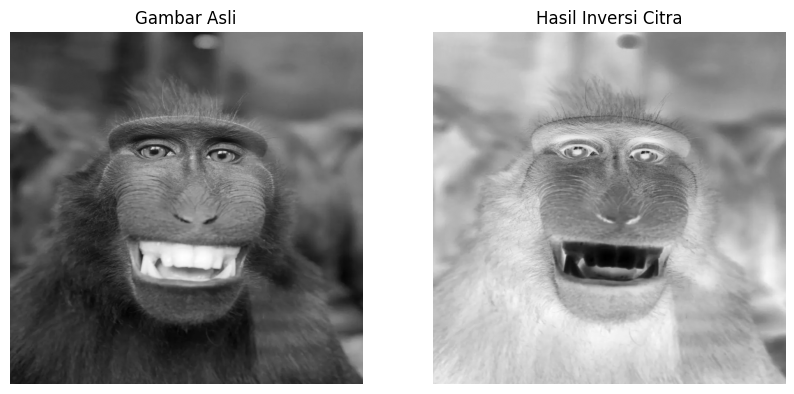

In [ ]:
def inverse_image():
    uploaded = files.upload()
    filename = next(iter(uploaded))

    image = Image.open(BytesIO(uploaded[filename]))
    image = image.convert("L")

    image_np = np.array(image, dtype=np.uint8)
    # inversi citra
    inverted_image = 255 - image_np

    # Tampilkan hasil
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Gambar Asli')
    axes[0].axis('off')

    axes[1].imshow(inverted_image, cmap='gray')
    axes[1].set_title('Hasil Inversi Citra')
    axes[1].axis('off')

    plt.show()

inverse_image()


## **8. Transformasi Log**

Saving Screenshot 2025-03-20 163156.png to Screenshot 2025-03-20 163156 (11).png


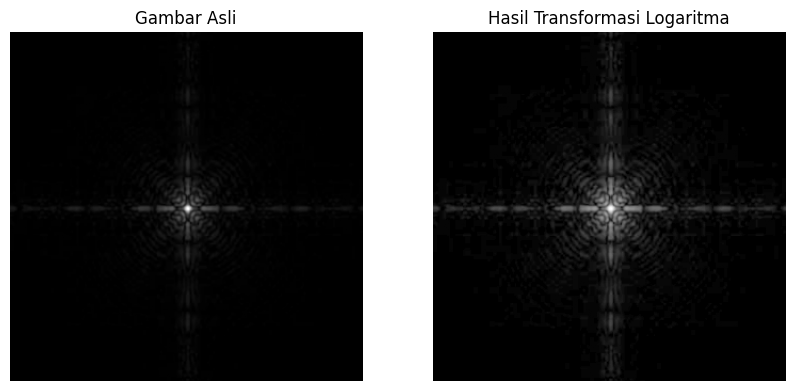

In [ ]:
def log_transform():
    uploaded = files.upload()
    for filename in uploaded.keys():
        image = Image.open(BytesIO(uploaded[filename]))
        image = image.convert("L")

        image_np = np.array(image, dtype=np.float32)
        c = 255 / np.log(1 + np.max(image_np))
        log_image = c * np.log1p(image_np)
        log_image = (log_image / np.max(log_image)) * 255
        log_image = log_image.astype(np.uint8)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(image, cmap='gray')
        axes[0].set_title('Gambar Asli')
        axes[0].axis('off')

        axes[1].imshow(log_image, cmap='gray')
        axes[1].set_title('Hasil Transformasi Logaritma')
        axes[1].axis('off')

        plt.show()
        break

log_transform()

## **9. Transformasi Pangkat / Power Gamma**

Saving Screenshot 2025-03-20 164806.png to Screenshot 2025-03-20 164806 (1).png


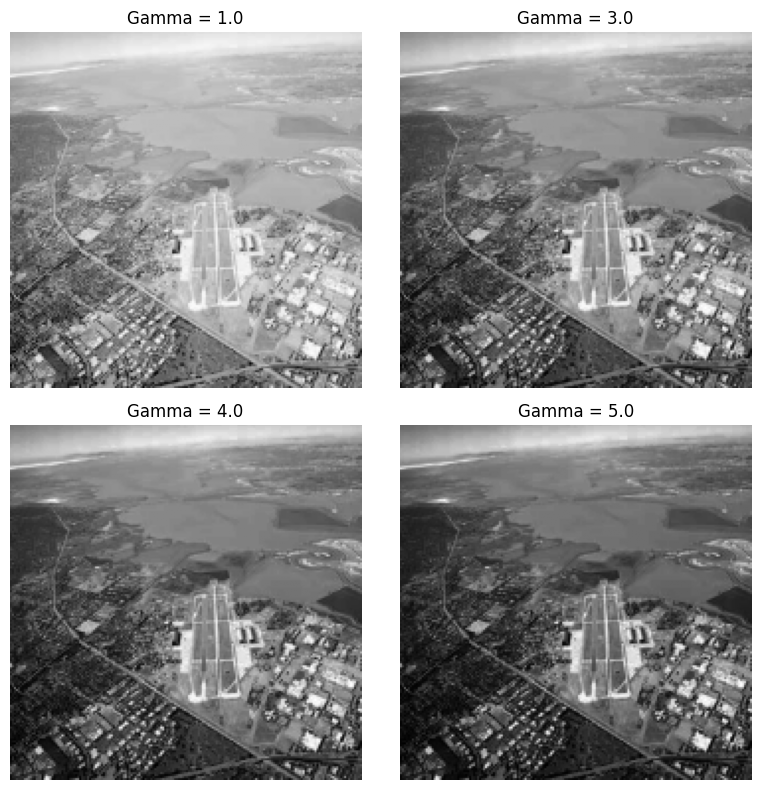

In [ ]:
def power_transform():
    uploaded = files.upload()
    for filename in uploaded.keys():
        image = Image.open(BytesIO(uploaded[filename]))
        image = image.convert("L")

        image_np = np.array(image, dtype=np.float32) / 255.0
        c = 1
        gamma_values = [1.0, 3.0, 4.0, 5.0]

        fig, axes = plt.subplots(2, 2, figsize=(8, 8))

        for ax, gamma in zip(axes.flat, gamma_values):
            power_image = c * (image_np ** gamma)
            power_image = (power_image / np.max(power_image)) * 255
            power_image = power_image.astype(np.uint8)

            ax.imshow(power_image, cmap='gray')
            ax.set_title(f'Gamma = {gamma}')
            ax.axis('off')

        plt.tight_layout()
        plt.show()
        break

power_transform()

## **10. Histogram Tingkat Keabuan**

Saving images (11).jpg to images (11).jpg


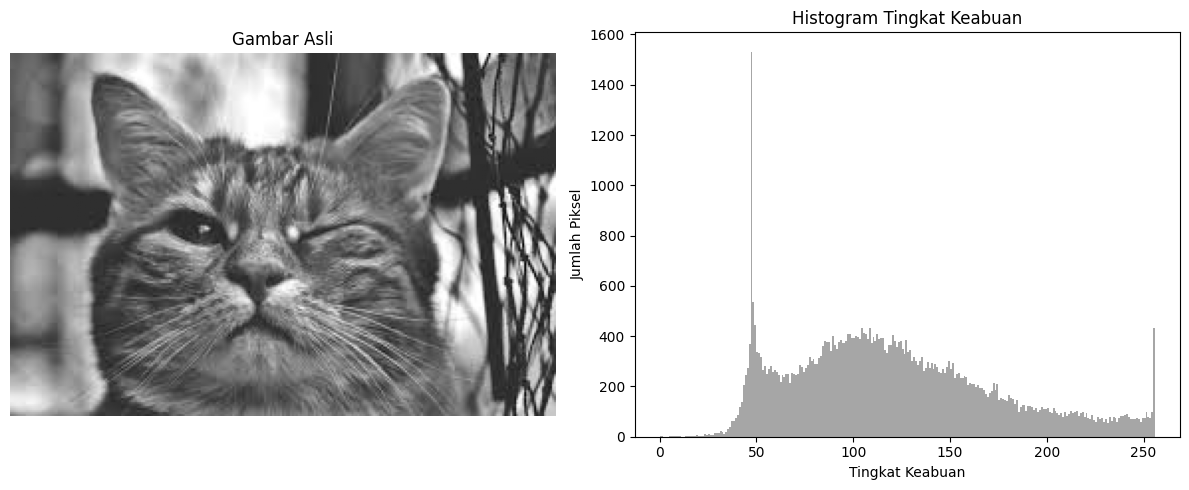

In [ ]:
def histogram_tingkat_keabuan():
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].imshow(image, cmap='gray')
    axs[0].set_title('Gambar Asli')
    axs[0].axis('off')

    axs[1].hist(image.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
    axs[1].set_title('Histogram Tingkat Keabuan')
    axs[1].set_xlabel('Tingkat Keabuan')
    axs[1].set_ylabel('Jumlah Piksel')

    plt.tight_layout()
    plt.show()

histogram_tingkat_keabuan()

## **11 a. Histogram Equalization (Perataan Histogram RGB)**

Saving haha.png to haha (38).png


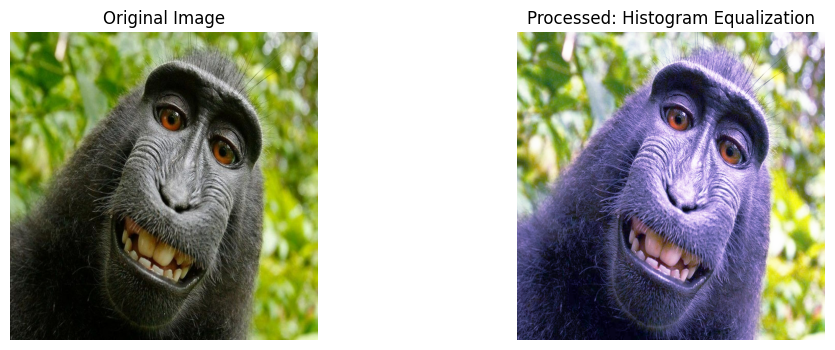

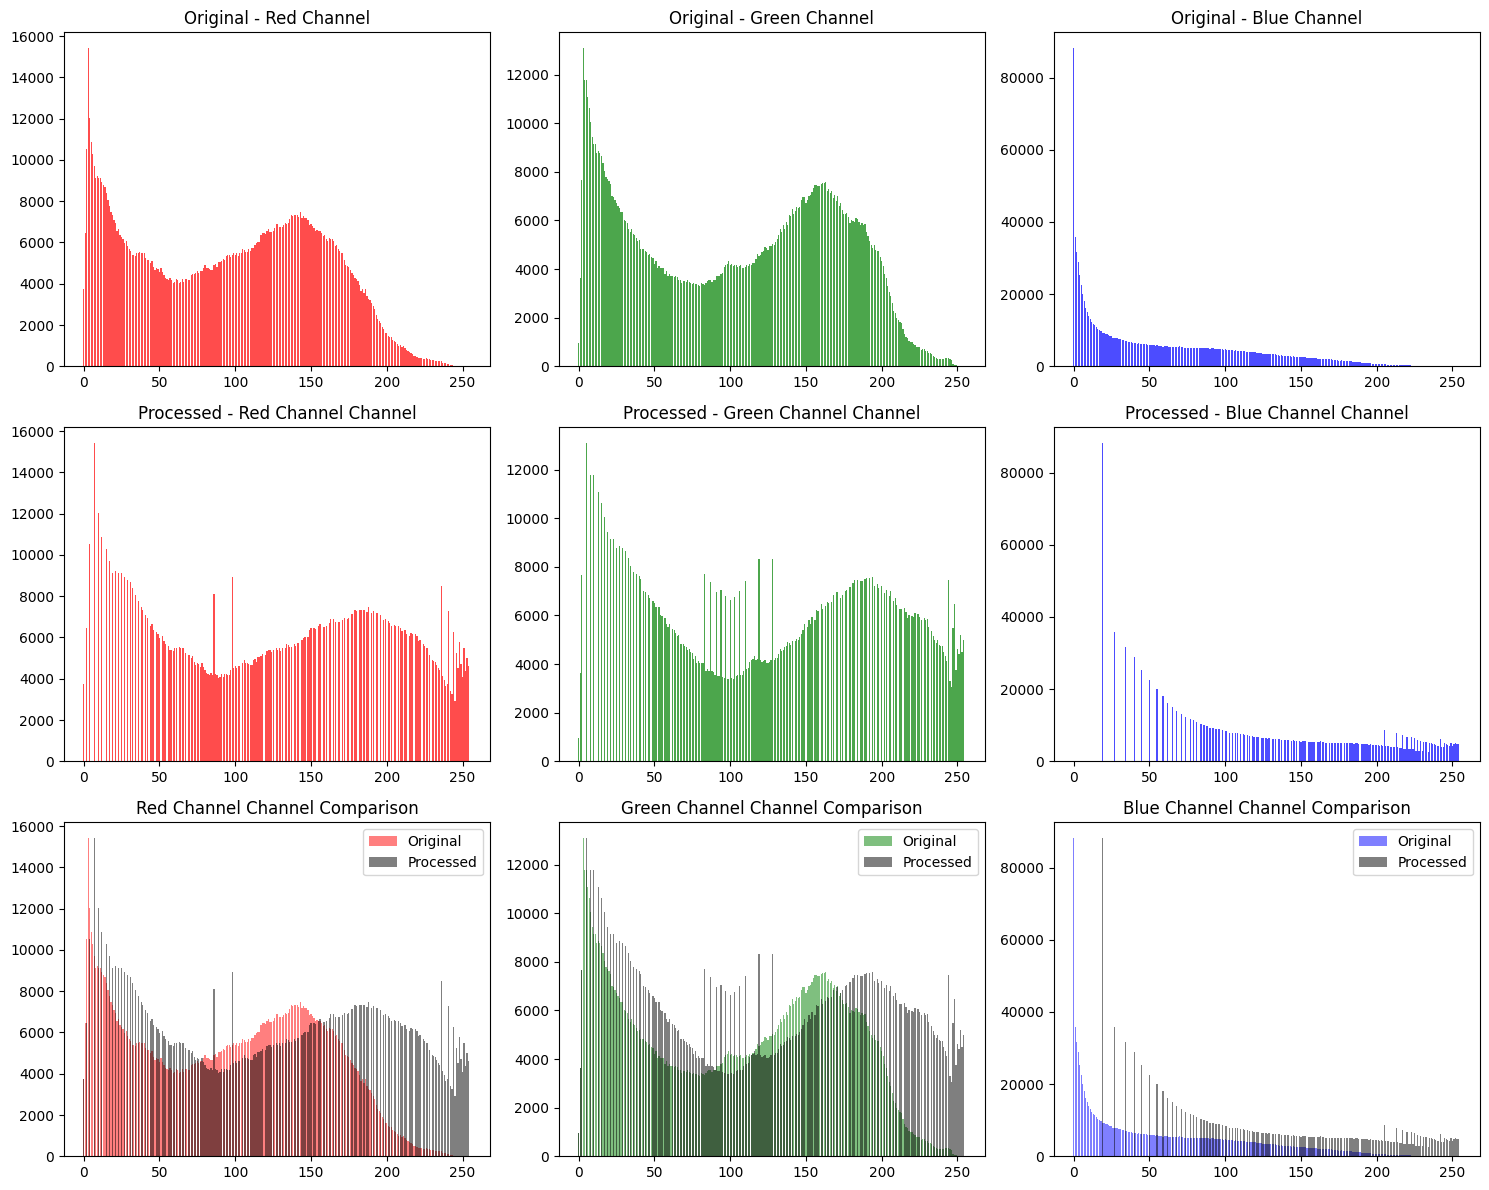

In [78]:
def calculate_histogram_rgb(image):
    img_np = np.array(image)
    hist_r = np.histogram(img_np[:, :, 0], bins=256, range=(0, 256))[0]
    hist_g = np.histogram(img_np[:, :, 1], bins=256, range=(0, 256))[0]
    hist_b = np.histogram(img_np[:, :, 2], bins=256, range=(0, 256))[0]
    return hist_r, hist_g, hist_b

def cumulative_histogram(hist):
    return np.cumsum(hist)

def histogram_equalization_rgb(image):
    img_np = np.array(image)
    height, width, _ = img_np.shape
    total_pixels = height * width

    hist_r, hist_g, hist_b = calculate_histogram_rgb(image)

    cum_hist_r = cumulative_histogram(hist_r)
    cum_hist_g = cumulative_histogram(hist_g)
    cum_hist_b = cumulative_histogram(hist_b)

    norm_cum_hist_r = (cum_hist_r * 255 / total_pixels).astype(np.uint8)
    norm_cum_hist_g = (cum_hist_g * 255 / total_pixels).astype(np.uint8)
    norm_cum_hist_b = (cum_hist_b * 255 / total_pixels).astype(np.uint8)

    equalized_img = np.zeros_like(img_np)
    for i in range(height):
        for j in range(width):
            equalized_img[i, j, 0] = norm_cum_hist_r[img_np[i, j, 0]]
            equalized_img[i, j, 1] = norm_cum_hist_g[img_np[i, j, 1]]
            equalized_img[i, j, 2] = norm_cum_hist_b[img_np[i, j, 2]]

    return Image.fromarray(equalized_img)

def upload_and_process():
    uploaded = files.upload()
    for filename in uploaded.keys():
        image = Image.open(BytesIO(uploaded[filename]))
        image = image.convert("RGB")

        equalized_image = histogram_equalization_rgb(image)

        hist_r, hist_g, hist_b = calculate_histogram_rgb(image)
        hist_eq_r, hist_eq_g, hist_eq_b = calculate_histogram_rgb(equalized_image)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].imshow(image)
        axes[0].set_title("Original Image")
        axes[0].axis('off')

        axes[1].imshow(equalized_image)
        axes[1].set_title("Processed: Histogram Equalization")
        axes[1].axis('off')

        plt.show()

        fig, axes = plt.subplots(3, 3, figsize=(15, 12))
        colors = ['red', 'green', 'blue']
        titles = ['Red Channel', 'Green Channel', 'Blue Channel']

        for i, (orig_hist, eq_hist, color, title) in enumerate(zip([hist_r, hist_g, hist_b],
                                                                   [hist_eq_r, hist_eq_g, hist_eq_b],
                                                                   colors, titles)):
            axes[0, i].bar(range(256), orig_hist, color=color, alpha=0.7)
            axes[0, i].set_title(f'Original - {title}')

            axes[1, i].bar(range(256), eq_hist, color=color, alpha=0.7)
            axes[1, i].set_title(f'Processed - {title} Channel')

            axes[2, i].bar(range(256), orig_hist, color=color, alpha=0.5, label='Original')
            axes[2, i].bar(range(256), eq_hist, color='black', alpha=0.5, label='Processed')
            axes[2, i].set_title(f'{title} Channel Comparison')
            axes[2, i].legend()

        plt.tight_layout()
        plt.show()

        break

upload_and_process()


## **11 b. Histogram Equalization (Perataan Histogram Grayscale)**

Saving haha.png to haha (46).png


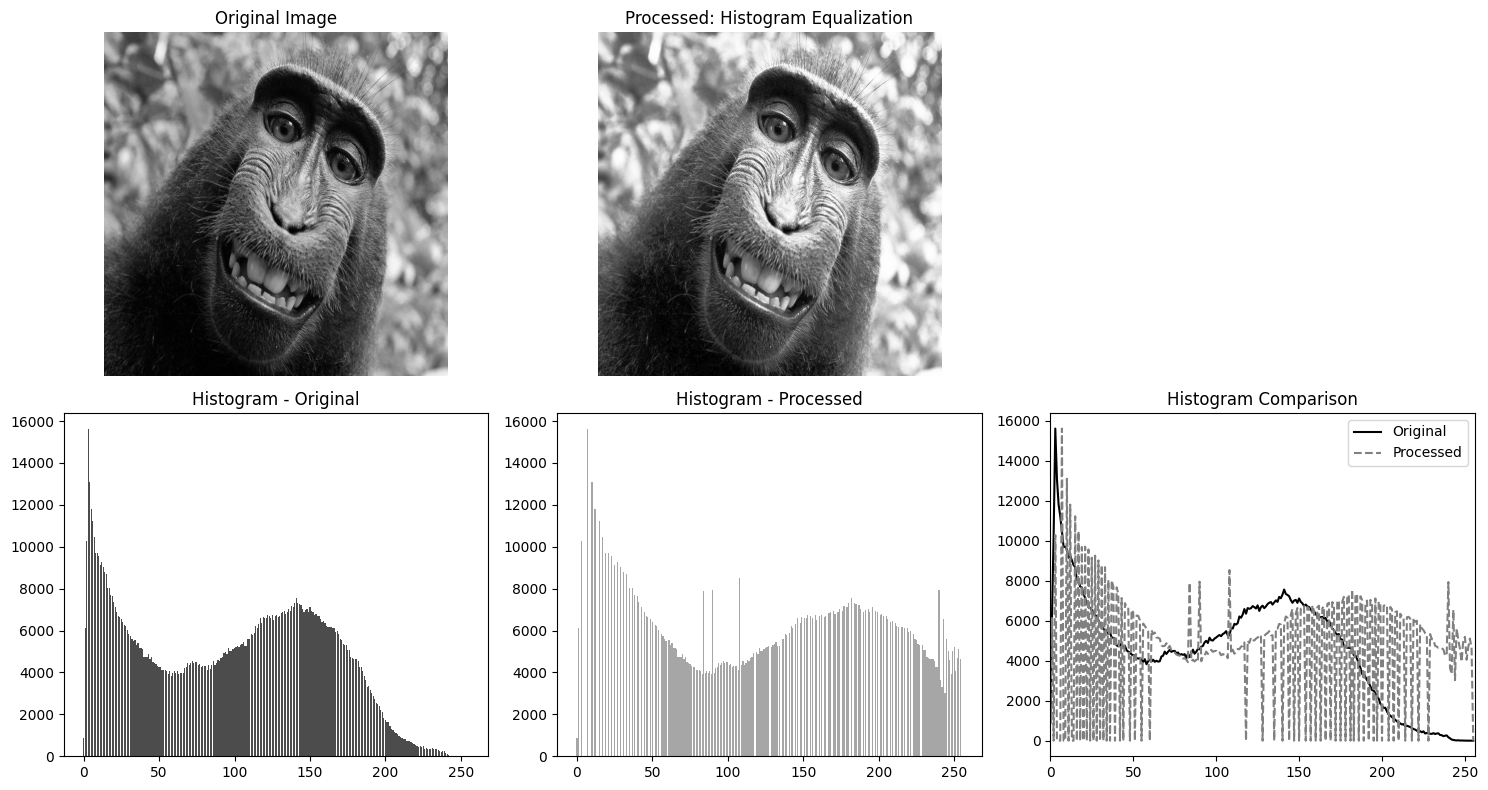

In [92]:
def calculate_histogram_gray(image):
    img_np = np.array(image)
    hist, _ = np.histogram(img_np, bins=256, range=(0, 256))
    return hist

def cumulative_histogram(hist):
    return np.cumsum(hist)

def histogram_equalization_gray(image):
    img_np = np.array(image)
    height, width = img_np.shape
    total_pixels = height * width

    hist = calculate_histogram_gray(image)
    cum_hist = cumulative_histogram(hist)

    norm_cum_hist = (cum_hist * 255 / total_pixels).astype(np.uint8)

    equalized_img = norm_cum_hist[img_np]

    return Image.fromarray(equalized_img)

def upload_and_process_gray():
    uploaded = files.upload()
    for filename in uploaded.keys():
        image = Image.open(BytesIO(uploaded[filename])).convert("L")

        equalized_image = histogram_equalization_gray(image)

        hist_original = calculate_histogram_gray(image)
        hist_equalized = calculate_histogram_gray(equalized_image)

        fig, axes = plt.subplots(2, 3, figsize=(15, 8))

        axes[0, 0].imshow(image, cmap="gray")
        axes[0, 0].set_title("Original Image")
        axes[0, 0].axis("off")

        axes[1, 0].bar(range(256), hist_original, color="black", alpha=0.7)
        axes[1, 0].set_title("Histogram - Original")

        axes[0, 1].imshow(equalized_image, cmap="gray")
        axes[0, 1].set_title("Processed: Histogram Equalization")
        axes[0, 1].axis("off")

        axes[1, 1].bar(range(256), hist_equalized, color="gray", alpha=0.7)
        axes[1, 1].set_title("Histogram - Processed")

        axes[1, 2].plot(hist_original, color="black", label="Original")
        axes[1, 2].plot(hist_equalized, color="gray", linestyle="dashed", label="Processed")
        axes[1, 2].set_title("Histogram Comparison")
        axes[1, 2].legend()
        axes[1, 2].set_xlim([0, 256])

        # Kosongkan area atas pada kolom 3 agar lebih rapi
        axes[0, 2].axis("off")

        plt.tight_layout()
        plt.show()

        break

upload_and_process_gray()


## **12. Histogram Piecewise Linear Transformation Functions (Contrast strecthing dan intensity-level slicing)**

### **Contrast Stretching**

Saving haha.png to haha (36).png


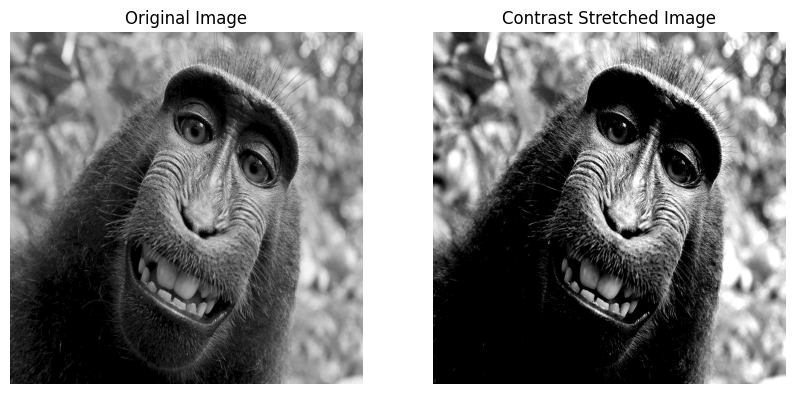

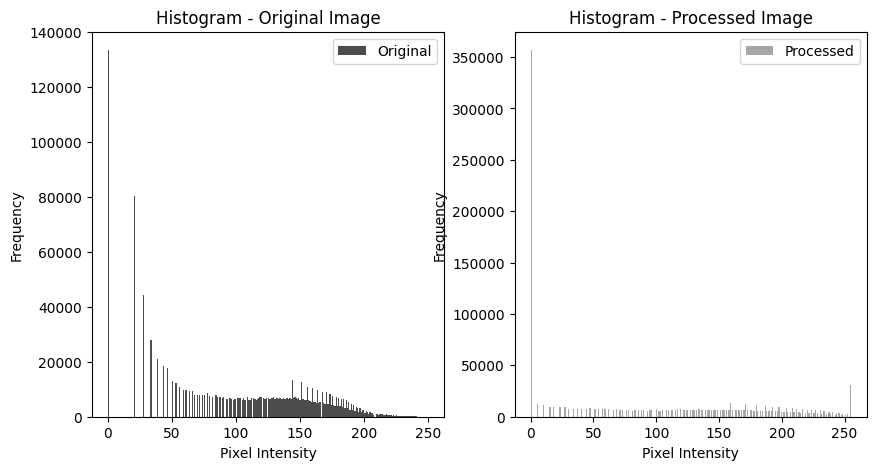

In [ ]:
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

img = cv2.imdecode(np.frombuffer(uploaded[file_name], np.uint8), cv2.IMREAD_GRAYSCALE)

def contrast_stretching(img, r1, s1, r2, s2):
    def piecewise_transform(pixel):
        if pixel < r1:
            return (s1 / r1) * pixel
        elif r1 <= pixel < r2:
            return ((s2 - s1) / (r2 - r1)) * (pixel - r1) + s1
        else:
            return ((255 - s2) / (255 - r2)) * (pixel - r2) + s2

    vectorized_transform = np.vectorize(piecewise_transform)
    return vectorized_transform(img).astype(np.uint8)

def plot_histograms(original, processed):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.hist(original.ravel(), bins=256, color='black', alpha=0.7, label='Original')
    plt.title("Histogram - Original Image")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.hist(processed.ravel(), bins=256, color='gray', alpha=0.7, label='Processed')
    plt.title("Histogram - Processed Image")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.legend()

    plt.show()

contrast_img = contrast_stretching(img, 50, 0, 200, 255)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(contrast_img, cmap='gray')
plt.title("Contrast Stretched Image")
plt.axis('off')

plt.show()

plot_histograms(img, contrast_img)


### **Intensity Level Slicing**

Saving haha.png to haha (37).png


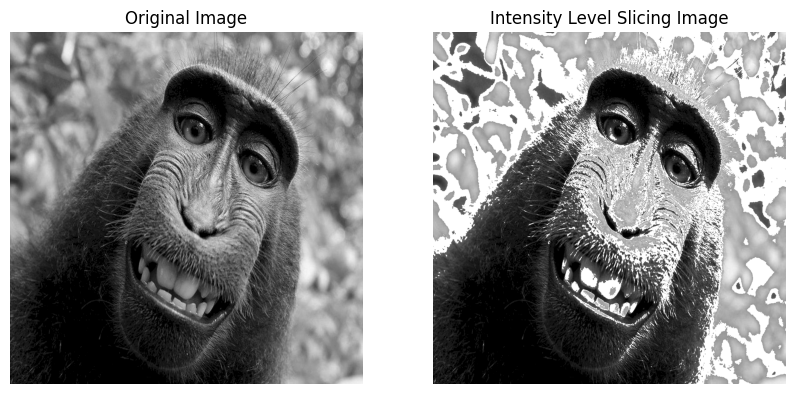

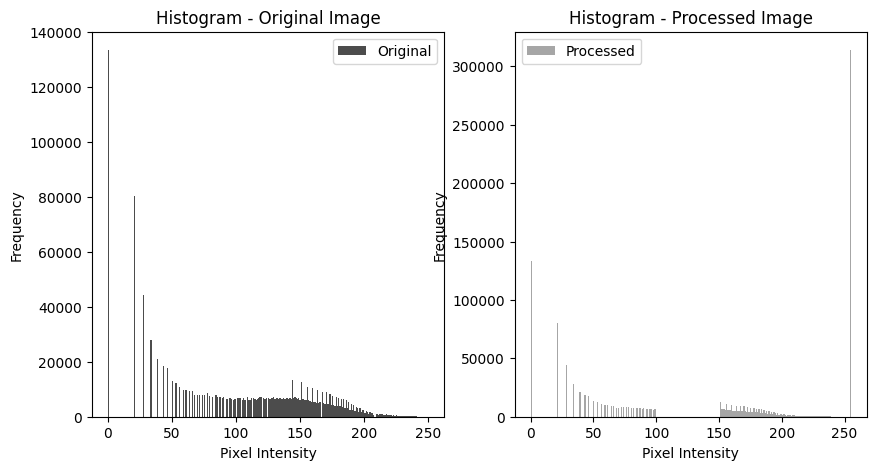

In [ ]:
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

img = cv2.imdecode(np.frombuffer(uploaded[file_name], np.uint8), cv2.IMREAD_GRAYSCALE)

def intensity_level_slicing(img, min_range, max_range, high_intensity=255, background=False):
    output = np.zeros_like(img)
    mask = (img >= min_range) & (img <= max_range)
    output[mask] = high_intensity
    if background:
        output[~mask] = img[~mask]
    return output

def plot_histograms(original, processed):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.hist(original.ravel(), bins=256, color='black', alpha=0.7, label='Original')
    plt.title("Histogram - Original Image")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.hist(processed.ravel(), bins=256, color='gray', alpha=0.7, label='Processed')
    plt.title("Histogram - Processed Image")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.legend()

    plt.show()

slicing_img = intensity_level_slicing(img, 100, 150, 255, background=True)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(slicing_img, cmap='gray')
plt.title("Intensity Level Slicing Image")
plt.axis('off')

plt.show()

plot_histograms(img, slicing_img)

## **13. Histogram Bit-plane slicing**

Saving ilustrasi-kucing-1_169.jpeg to ilustrasi-kucing-1_169 (4).jpeg


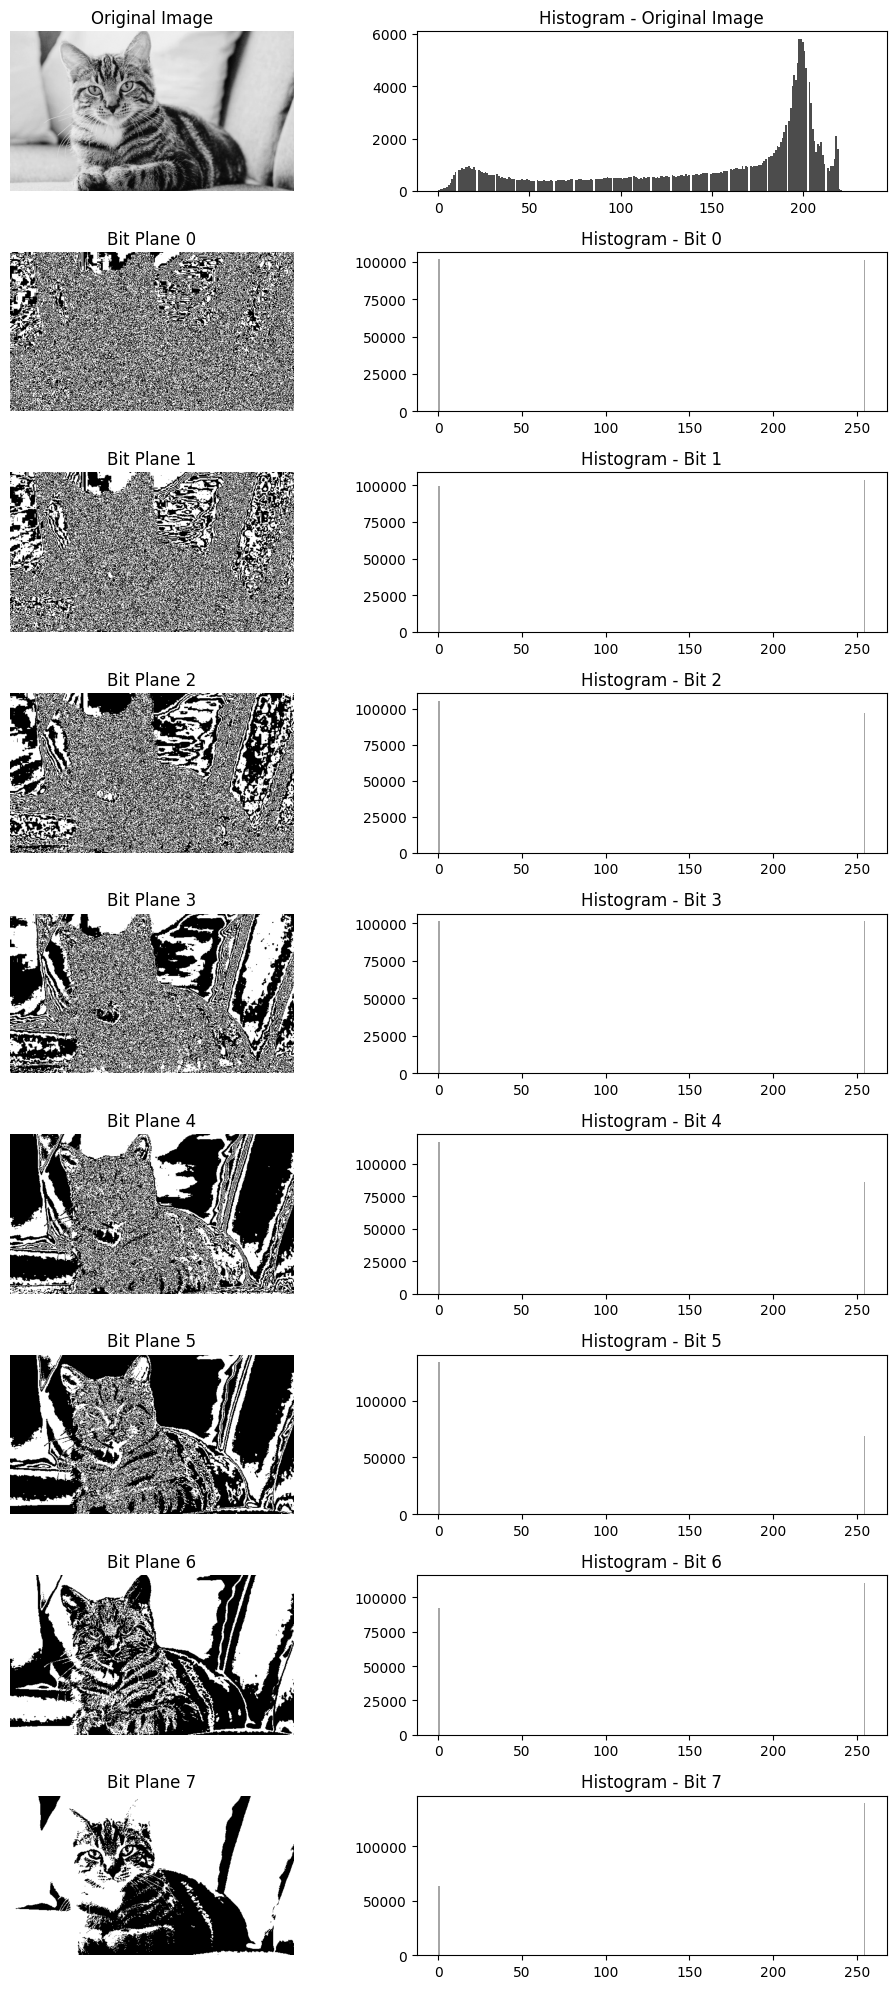

In [ ]:
def bit_plane_slicing():
    uploaded = files.upload()
    for filename in uploaded.keys():
        img = Image.open(io.BytesIO(uploaded[filename]))
        img = img.convert('L')
        img = np.array(img)

    bit_planes = []

    for i in range(8):
        bit_plane = (img & (1 << i)) >> i
        bit_plane = bit_plane * 255
        bit_planes.append(bit_plane)

    fig, axes = plt.subplots(9, 2, figsize=(10, 20))

    axes[0, 0].imshow(img, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    axes[0, 1].hist(img.ravel(), bins=256, color='black', alpha=0.7)
    axes[0, 1].set_title('Histogram - Original Image')

    for i in range(8):
        axes[i + 1, 0].imshow(bit_planes[i], cmap='gray')
        axes[i + 1, 0].set_title(f'Bit Plane {i}')
        axes[i + 1, 0].axis('off')

        axes[i + 1, 1].hist(bit_planes[i].ravel(), bins=256, color='gray', alpha=0.7)
        axes[i + 1, 1].set_title(f'Histogram - Bit {i}')

    plt.tight_layout()
    plt.show()

bit_plane_slicing()


## **14. Lokal Histogram Processing**

Saving ilustrasi-kucing-1_169.jpeg to ilustrasi-kucing-1_169 (8).jpeg


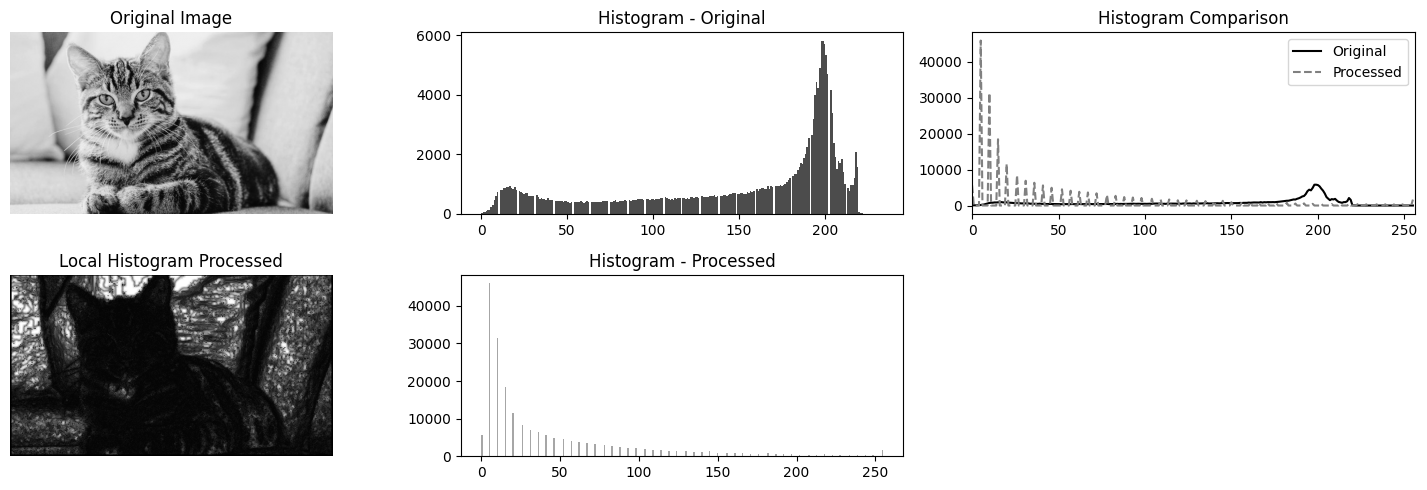

In [85]:
def process_local_histogram(image_path, kernel_size=3):
    img = Image.open(image_path).convert('L')
    img = np.array(img)

    # local Histogram Processing
    k = kernel_size // 2
    height, width = img.shape
    processed_img = np.zeros_like(img)

    for i in range(k, height - k):
        for j in range(k, width - k):
            local_region = img[i - k:i + k + 1, j - k:j + k + 1]
            hist, _ = np.histogram(local_region, bins=256, range=(0, 256))

            # normalisasi histogram menggunakan rumus
            M, N = local_region.shape
            normalized_hist = hist / (M * N)

            pixel_value = img[i, j]
            processed_img[i, j] = int(normalized_hist[pixel_value] * 255)

    plt.figure(figsize=(15, 5))

    plt.subplot(2, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.hist(img.ravel(), bins=256, color='black', alpha=0.7)
    plt.title("Histogram - Original")

    plt.subplot(2, 3, 4)
    plt.imshow(processed_img, cmap='gray')
    plt.title("Local Histogram Processed")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.hist(processed_img.ravel(), bins=256, color='gray', alpha=0.7)
    plt.title("Histogram - Processed")

    plt.subplot(2, 3, 3)
    hist_original, _ = np.histogram(img.ravel(), bins=256, range=(0, 256))
    hist_processed, _ = np.histogram(processed_img.ravel(), bins=256, range=(0, 256))
    plt.plot(hist_original, color='black', label="Original")
    plt.plot(hist_processed, color='gray', linestyle='dashed', label="Processed")
    plt.title("Histogram Comparison")
    plt.legend()
    plt.xlim([0, 256])

    plt.tight_layout()
    plt.show()

uploaded = files.upload()
for filename in uploaded.keys():
    process_local_histogram(io.BytesIO(uploaded[filename]), kernel_size=7)

## **15. Pengubahan Histogram (Spesifikasi Histogram)**

Saving haha.png to haha (44).png
Saving monyet.png to monyet (2).png


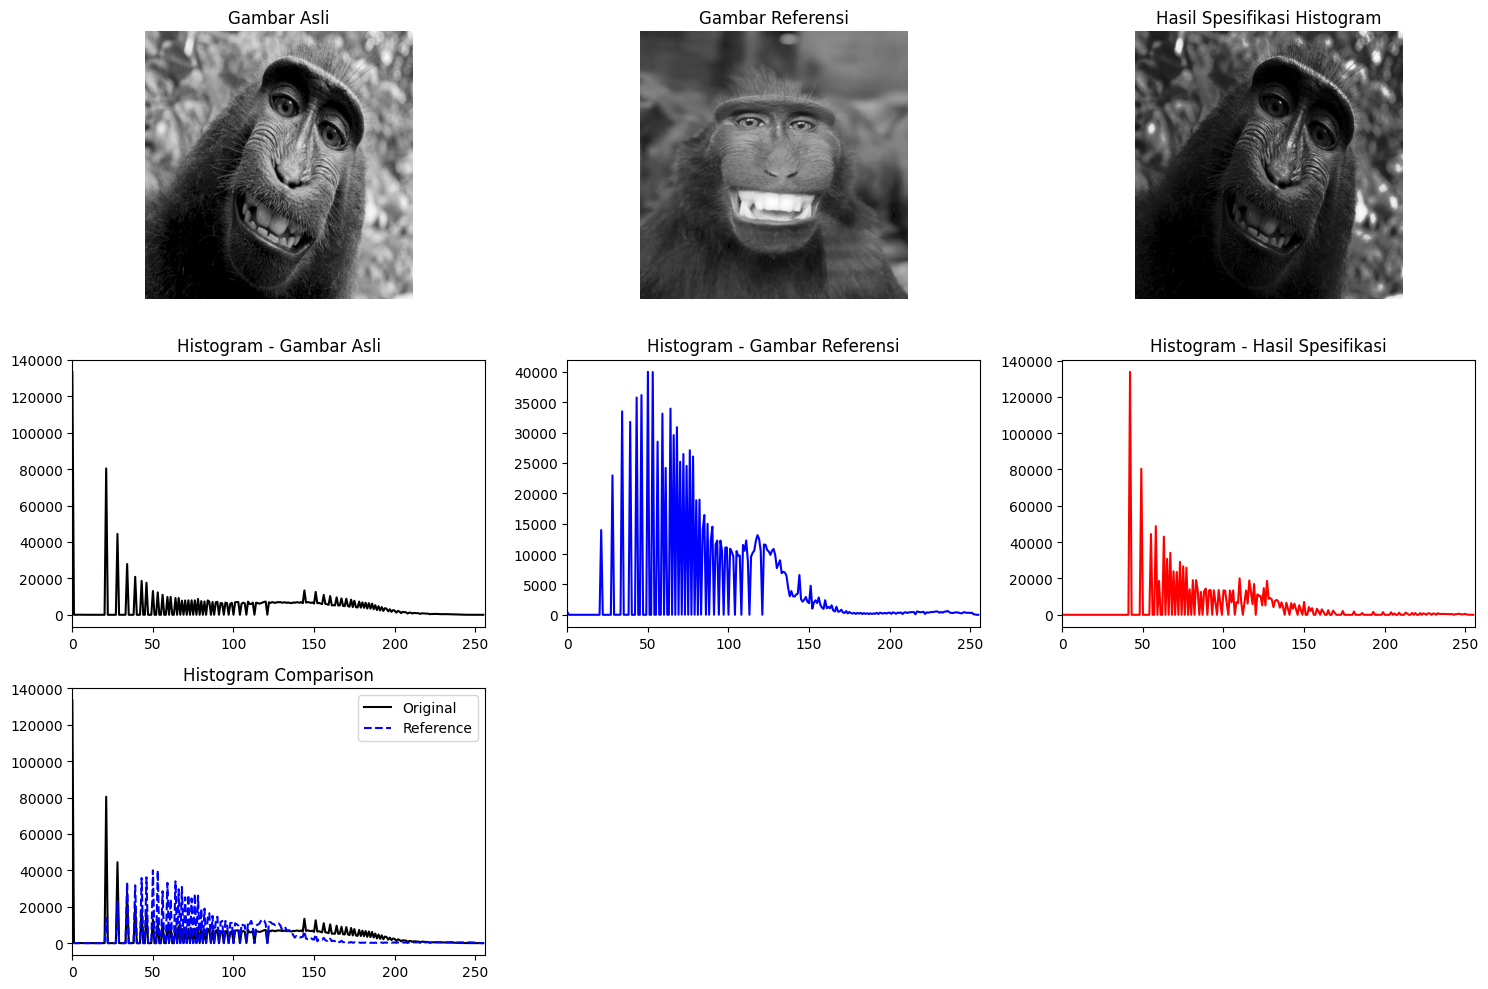

In [90]:
def compute_cdf(hist):
    cdf = hist.cumsum()
    cdf_normalized = cdf / cdf[-1]
    return cdf_normalized

def match_histogram(source, reference):
    source_hist, _ = np.histogram(source.flatten(), bins=256, range=[0, 256])
    reference_hist, _ = np.histogram(reference.flatten(), bins=256, range=[0, 256])

    source_cdf = compute_cdf(source_hist)
    reference_cdf = compute_cdf(reference_hist)

    mapping = np.interp(source_cdf, reference_cdf, np.arange(256))
    matched_image = mapping[source].astype(np.uint8)

    return matched_image

def plot_histogram(image, title, color):
    hist, _ = np.histogram(image.flatten(), bins=256, range=[0, 256])
    plt.plot(hist, color=color)
    plt.title(title)
    plt.xlim([0, 256])

def spesifikasi_histogram():
    uploaded = files.upload()
    source = list(uploaded.keys())[0]
    reference = list(uploaded.keys())[1]

    source_image = cv2.imread(source, cv2.IMREAD_GRAYSCALE)
    reference_image = cv2.imread(reference, cv2.IMREAD_GRAYSCALE)

    matched_image = match_histogram(source_image, reference_image)

    plt.figure(figsize=(15, 10))

    plt.subplot(3, 3, 1)
    plt.imshow(source_image, cmap='gray')
    plt.title("Gambar Asli")
    plt.axis("off")

    plt.subplot(3, 3, 2)
    plt.imshow(reference_image, cmap='gray')
    plt.title("Gambar Referensi")
    plt.axis("off")

    plt.subplot(3, 3, 3)
    plt.imshow(matched_image, cmap='gray')
    plt.title("Hasil Spesifikasi Histogram")
    plt.axis("off")

    plt.subplot(3, 3, 4)
    plot_histogram(source_image, "Histogram - Gambar Asli", "black")

    plt.subplot(3, 3, 5)
    plot_histogram(reference_image, "Histogram - Gambar Referensi", "blue")

    plt.subplot(3, 3, 6)
    plot_histogram(matched_image, "Histogram - Hasil Spesifikasi", "red")

    plt.subplot(3, 3, 7)
    hist_source, _ = np.histogram(source_image.flatten(), bins=256, range=[0, 256])
    hist_reference, _ = np.histogram(reference_image.flatten(), bins=256, range=[0, 256])
    hist_matched, _ = np.histogram(matched_image.flatten(), bins=256, range=[0, 256])

    plt.plot(hist_source, color="black", label="Original")
    plt.plot(hist_reference, color="blue", linestyle="dashed", label="Reference")
    plt.title("Histogram Comparison")
    plt.legend()
    plt.xlim([0, 256])

    plt.tight_layout()
    plt.show()

spesifikasi_histogram()
